# Ejemplo 2 — PSO para Hyperparameter Tuning

**Actividad 03 — Algoritmos de Enjambre aplicados al Aprendizaje Automático**

## Objetivo

Usar **Particle Swarm Optimization (PSO)** para buscar buenos hiperparámetros de una máquina de vectores de soporte (`SVC`) sobre el dataset Breast Cancer.

### Partícula

Cada partícula contiene dos posiciones continuas:

- `x[0] = log10(C)`
- `x[1] = log10(gamma)`

Se optimizan en escala logarítmica porque ambos hiperparámetros pueden variar varios órdenes de magnitud.

### Ciclo

- representación de partícula;
- inicialización del enjambre;
- evaluación de aptitud;
- actualización de velocidad;
- actualización de posición;
- mejor personal (`pbest`);
- mejor global (`gbest`);
- finalización.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

SEMILLA = 42
datos = load_breast_cancer()

X_train_total, X_test, y_train_total, y_test = train_test_split(
    datos.data, datos.target,
    test_size=0.20,
    stratify=datos.target,
    random_state=SEMILLA
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_total, y_train_total,
    test_size=0.25,
    stratify=y_train_total,
    random_state=SEMILLA
)

print("Dataset Breast Cancer")
print("Train:", X_train.shape)
print("Validación:", X_val.shape)
print("Test:", X_test.shape)

Dataset Breast Cancer
Train: (341, 30)
Validación: (114, 30)
Test: (114, 30)


## Función de aptitud

La calidad de una partícula es el **accuracy en validación** del SVC construido con sus valores de `C` y `gamma`.

PSO maximizará esa métrica.

In [2]:
# Límites en escala log10
# C:     10^-3 a 10^3
# gamma: 10^-4 a 10^1
LIMITES = np.array([
    [-3.0,  3.0],
    [-4.0,  1.0]
])

cache = {}

def decodificar_particula(posicion):
    log10_C = float(posicion[0])
    log10_gamma = float(posicion[1])

    C = 10 ** log10_C
    gamma = 10 ** log10_gamma

    return C, gamma

def evaluar_particula(posicion):
    # Redondeo solo para usar caché y no repetir evaluaciones casi idénticas
    clave = tuple(np.round(posicion, 4))
    if clave in cache:
        return cache[clave]

    C, gamma = decodificar_particula(posicion)

    modelo = make_pipeline(
        StandardScaler(),
        SVC(C=C, gamma=gamma, kernel="rbf")
    )
    modelo.fit(X_train, y_train)
    accuracy = accuracy_score(y_val, modelo.predict(X_val))

    cache[clave] = accuracy
    return accuracy

## PSO completo

La actualización utiliza:

- **inercia:** conserva parte de la dirección anterior;
- **componente cognitiva:** atrae a la partícula hacia su mejor posición personal;
- **componente social:** atrae hacia la mejor posición global del enjambre.

In [3]:
def pso_hiperparametros(
    numero_particulas=10,
    iteraciones=12,
    w=0.72,
    c1=1.49,
    c2=1.49
):
    rng = np.random.default_rng(SEMILLA)
    cache.clear()

    minimo = LIMITES[:, 0]
    maximo = LIMITES[:, 1]
    dimensiones = len(minimo)

    # Inicialización
    posiciones = rng.uniform(
        minimo, maximo,
        size=(numero_particulas, dimensiones)
    )
    velocidades = np.zeros_like(posiciones)

    fitness_actual = np.array([
        evaluar_particula(p) for p in posiciones
    ])

    pbest_posiciones = posiciones.copy()
    pbest_fitness = fitness_actual.copy()

    indice_gbest = int(np.argmax(pbest_fitness))
    gbest_posicion = pbest_posiciones[indice_gbest].copy()
    gbest_fitness = pbest_fitness[indice_gbest]

    historial = []

    print("INICIO PSO - HYPERPARAMETER TUNING")
    print("=" * 80)

    for it in range(1, iteraciones + 1):
        r1 = rng.random(posiciones.shape)
        r2 = rng.random(posiciones.shape)

        # Comportamiento de cada partícula: actualización de velocidad
        velocidades = (
            w * velocidades
            + c1 * r1 * (pbest_posiciones - posiciones)
            + c2 * r2 * (gbest_posicion - posiciones)
        )

        # Evolución: nueva posición
        posiciones = posiciones + velocidades
        posiciones = np.clip(posiciones, minimo, maximo)

        fitness_actual = np.array([
            evaluar_particula(p) for p in posiciones
        ])

        # Actualizar mejores personales
        mejoraron = fitness_actual > pbest_fitness
        pbest_posiciones[mejoraron] = posiciones[mejoraron]
        pbest_fitness[mejoraron] = fitness_actual[mejoraron]

        # Actualizar mejor global
        indice = int(np.argmax(pbest_fitness))
        if pbest_fitness[indice] > gbest_fitness:
            gbest_posicion = pbest_posiciones[indice].copy()
            gbest_fitness = pbest_fitness[indice]

        C, gamma = decodificar_particula(gbest_posicion)

        historial.append({
            "iteracion": it,
            "mejor_accuracy": gbest_fitness,
            "C": C,
            "gamma": gamma
        })

        print(
            f"Iteración {it:02d} | "
            f"Mejor accuracy: {gbest_fitness:.4f} | "
            f"C: {C:.4f} | gamma: {gamma:.6f}"
        )

    return gbest_posicion, gbest_fitness, pd.DataFrame(historial)

mejor_posicion_pso, mejor_accuracy_val, historial_pso = pso_hiperparametros()

INICIO PSO - HYPERPARAMETER TUNING
Iteración 01 | Mejor accuracy: 0.9825 | C: 41.8503 | gamma: 0.076789


Iteración 02 | Mejor accuracy: 0.9912 | C: 4.1129 | gamma: 0.065724
Iteración 03 | Mejor accuracy: 0.9912 | C: 4.1129 | gamma: 0.065724


Iteración 04 | Mejor accuracy: 0.9912 | C: 4.1129 | gamma: 0.065724


Iteración 05 | Mejor accuracy: 0.9912 | C: 4.1129 | gamma: 0.065724
Iteración 06 | Mejor accuracy: 0.9912 | C: 4.1129 | gamma: 0.065724
Iteración 07 | Mejor accuracy: 0.9912 | C: 4.1129 | gamma: 0.065724


Iteración 08 | Mejor accuracy: 0.9912 | C: 4.1129 | gamma: 0.065724


Iteración 09 | Mejor accuracy: 0.9912 | C: 4.1129 | gamma: 0.065724
Iteración 10 | Mejor accuracy: 0.9912 | C: 4.1129 | gamma: 0.065724


Iteración 11 | Mejor accuracy: 0.9912 | C: 4.1129 | gamma: 0.065724
Iteración 12 | Mejor accuracy: 0.9912 | C: 4.1129 | gamma: 0.065724


In [4]:
# Evaluación final en TEST
mejor_C, mejor_gamma = decodificar_particula(mejor_posicion_pso)

modelo_final = make_pipeline(
    StandardScaler(),
    SVC(C=mejor_C, gamma=mejor_gamma, kernel="rbf")
)
modelo_final.fit(X_train_total, y_train_total)
pred_test = modelo_final.predict(X_test)
accuracy_test = accuracy_score(y_test, pred_test)

print("\nRESULTADO FINAL PSO")
print("=" * 60)
print(f"Mejor C: {mejor_C:.6f}")
print(f"Mejor gamma: {mejor_gamma:.8f}")
print(f"Accuracy de validación encontrado: {mejor_accuracy_val:.4f}")
print(f"Accuracy final en test: {accuracy_test:.4f}")


RESULTADO FINAL PSO
Mejor C: 4.112947
Mejor gamma: 0.06572440
Accuracy de validación encontrado: 0.9912
Accuracy final en test: 0.9737


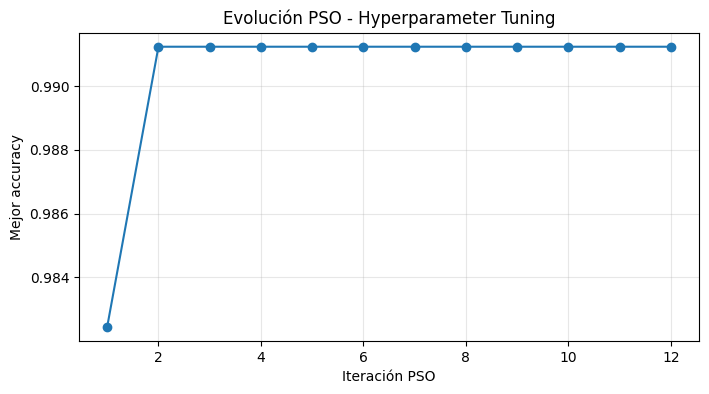

In [5]:
plt.figure(figsize=(8, 4))
plt.plot(historial_pso["iteracion"], historial_pso["mejor_accuracy"], marker="o")
plt.xlabel("Iteración PSO")
plt.ylabel("Mejor accuracy")
plt.title("Evolución PSO - Hyperparameter Tuning")
plt.grid(alpha=0.3)
plt.show()